# Normalizing flow — phase space with **simple** bijections

The main project learns the initial DF $f_0(z_0,w_0)$ with a **RealNVP** flow
(thousands of parameters) while jointly optimising the Hamiltonian flow to
recover the dark-matter scale height $h_{\rm dm}$.

But in the toy set-up the **true** $f_0$ is a single 2-D Gaussian, and the model
DF is Gaussian too.  So the bijection from a standard-normal base $u$ to the
data only has to **rescale and shift** each axis — a plain linear map
$F(u)=a\,u+b$ with **4 numbers** $(a_z,a_w,b_z,b_w)$ does it exactly.  A giant
RealNVP is overkill.

This notebook makes that point with two minimal models, each fitted **jointly
with $h_{\rm dm}$** on the same clean data:

* **Test A** — the bijection is the linear map $F(u)=a\,u+b$ (**4 parameters**).
  We check that the fit recovers $a\!\approx\!(\sigma_{z_0},\sigma_{w_0})$,
  $b\!\approx\!0$, *and* the true $h_{\rm dm}$.
* **Test B** — the bijection is a **tiny neural network with only 8 parameters**
  (two RealNVP-style coupling layers, one hidden non-linearity).  We check
  $h_{\rm dm}$ is still reproduced.

Both use the identical joint-MLE recipe as the full project
(`torch_back_integrate` + Liouville): maximise
$\;\sum_i \log f_0\big(T_{h}(z_i,w_i)\big)$, where $T_h$ back-integrates each
observed star to $t=0$.


In [1]:
# ============================================================================
# Setup: simulation, clean single-Gaussian data, and the shared joint-fit loop.
#   Data: N stars drawn from a centred 2-D Gaussian f0 (sigma z0_sigma, w0_sigma),
#   evolved forward for t_obs in the true potential (h_true), NO satellite.
#   This is the same clean-data recipe used by Test 9 of the main notebook.
# ============================================================================
import importlib, math, time
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from phase_space_simulation import Widmark1DSimulation, Widmark1DAnalysis
import fitter
importlib.reload(fitter)
from fitter import torch_back_integrate

h_true, t_obs = 250.0, 400.0
sim = Widmark1DSimulation(h_pc_dm=h_true)

# equilibrium relation sigma_z0 = sigma_w0 / nu (nu = midplane vertical freq)
w0_sigma = 20.0
nu = math.sqrt(4.0*math.pi*sim.G*(sim.rho0_thin+sim.rho0_thick+sim.rho0_gas+sim.rho_DM))
z0_sigma = w0_sigma / nu
print(f"true h_dm = {h_true:.0f} pc,  t_obs = {t_obs:.0f} Myr")
print(f"true f0 is a centred 2-D Gaussian:  sigma_z0 = {z0_sigma:.2f} pc,  "
      f"sigma_w0 = {w0_sigma:.2f} km/s")

# ---- generate the observed snapshot ----
N = 2000
z0, w0 = sim.sample_near_midplane(N=N, z_sigma_pc=z0_sigma, w_sigma_kms=w0_sigma, seed=7)
Zs, Ws, _ = sim.evolve_record(z0, w0, t_obs_myr=t_obs, n_steps=12000, n_snaps=10,
                              seed=0, use_satellite=False, h_pc_dm=h_true)
z_obs, w_obs = Zs[-1].astype(np.float64), Ws[-1].astype(np.float64)

# ---- shared joint MLE:  fit (flow params, h) together ----
def joint_fit(make_flow, h_init, n_epochs=300, ns=1000, n_sub=500,
              lr_flow=5e-2, lr_h=2.0, seed=0):
    """make_flow() -> an nn.Module with .log_prob(z,w). Returns (flow, h_fit, h_history)."""
    torch.manual_seed(seed); rng = np.random.default_rng(seed)
    flow = make_flow()
    h = nn.Parameter(torch.tensor(float(h_init), dtype=torch.float64))
    opt = torch.optim.Adam([{'params': flow.parameters(), 'lr': lr_flow},
                            {'params': [h],               'lr': lr_h}])
    hist = []
    for ep in range(n_epochs):
        idx = rng.choice(z_obs.size, size=n_sub, replace=False)
        zb, wb = torch_back_integrate(torch.tensor(z_obs[idx]), torch.tensor(w_obs[idx]),
                                      t_obs, h, sim, n_steps=ns)
        loss = -flow.log_prob(zb, wb).mean()
        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_([h], max_norm=50.0)
        opt.step()
        with torch.no_grad():
            h.clamp_(50.0, 800.0)
        hist.append(h.item())
    return flow, h.item(), hist

# back-integrate the full cloud at a given h (for plotting the recovered f0)
def backint(h, ns=2000):
    with torch.no_grad():
        zb, wb = torch_back_integrate(torch.tensor(z_obs), torch.tensor(w_obs),
                                      t_obs, torch.tensor(float(h)), sim, n_steps=ns)
    return zb.numpy(), wb.numpy()

# ---- helpers for the profile-likelihood and marginal plots (shared A & B) ----
def gauss_pdf(x, mu, s):
    return np.exp(-0.5*((x-mu)/s)**2) / (math.sqrt(2*math.pi)*s)

def cross(hs, d, level, side):
    """Linear-interp h where the (Delta)NLL curve d crosses `level`, walking
    outward from the minimum in the +/- `side` direction (matches Test 10)."""
    k = int(np.argmin(d))
    rng_ = range(k, len(hs)-1) if side > 0 else range(k, 0, -1)
    for i in rng_:
        j = i+1 if side > 0 else i-1
        if (d[i]-level)*(d[j]-level) <= 0 and d[j] != d[i]:
            f = (level-d[i])/(d[j]-d[i]); return hs[i] + f*(hs[j]-hs[i])
    return hs[-1] if side > 0 else hs[0]

def fitted_marginals(flow, zb, wb, pad=0.15, ng=220):
    """1-D marginals of a fitted 2-D density flow, by grid integration."""
    zlo, zhi = zb.min(), zb.max(); wlo, whi = wb.min(), wb.max()
    zg = np.linspace(zlo-(zhi-zlo)*pad, zhi+(zhi-zlo)*pad, ng)
    wg = np.linspace(wlo-(whi-wlo)*pad, whi+(whi-wlo)*pad, ng)
    ZG, WG = np.meshgrid(zg, wg)                       # shape (len(wg), len(zg))
    with torch.no_grad():
        p = np.exp(flow.log_prob(torch.tensor(ZG.ravel()),
                                 torch.tensor(WG.ravel())).numpy()).reshape(ZG.shape)
    dz, dw = zg[1]-zg[0], wg[1]-wg[0]
    return zg, p.sum(axis=0)*dw, wg, p.sum(axis=1)*dz   # (zg, m_z, wg, m_w)

def plot_marginals(axz, axw, flow, h_fit):
    """Draw the z0 and w0 marginals: samples + true Gaussian f0 + fitted f0."""
    zb, wb = backint(h_fit)
    zg, mz, wg, mw = fitted_marginals(flow, zb, wb)
    for ax, samp, grid, marg, s_true, lab, unit in [
            (axz, zb, zg, mz, z0_sigma, 'z_0', 'pc'),
            (axw, wb, wg, mw, w0_sigma, 'w_0', 'km/s')]:
        ax.hist(samp, bins=45, density=True, alpha=0.35, color='C0',
                label='back-integrated samples')
        ax.plot(grid, gauss_pdf(grid, 0.0, s_true), 'k--', lw=2,
                label=fr'true $f_0$: $\mathcal{{N}}(0,{s_true:.1f})$')
        ax.plot(grid, marg, color='C3', lw=2, label='fitted $f_0$ marginal')
        ax.set_xlabel(fr'${lab}$ [{unit}]'); ax.set_ylabel('density')
        ax.legend(fontsize=8)

print(f"generated N={N} observed stars.")


true h_dm = 250 pc,  t_obs = 400 Myr
true f0 is a centred 2-D Gaussian:  sigma_z0 = 259.39 pc,  sigma_w0 = 20.00 km/s


generated N=2000 observed stars.


## Test A — linear bijection $F(u)=a\,u+b$ (4 parameters)

The model DF is a **diagonal Gaussian**: base $u\sim\mathcal N(0,I_2)$ mapped by
$$ (z_0,w_0) = F(u) = a\odot u + b, \qquad a=(a_z,a_w),\; b=(b_z,b_w). $$
Its log-density is closed-form,
$\log f_0(x) = -\tfrac12\lVert (x-b)/a\rVert^2 - \log(2\pi) - \log a_z - \log a_w$,
so there are exactly **4 trainable numbers** — no neural network at all.

We fit $(a,b,h_{\rm dm})$ jointly from two very different starting values of
$h$.  Success = both runs land on the **same** $h\approx250$ (a genuine
minimum, not an init artefact) **and** $a\to(\sigma_{z_0},\sigma_{w_0})$,
$b\to 0$.


DiagonalAffineFlow parameter count = 4  (a_z, a_w, b_z, b_w)



  init h=180 -> h_fit= 261.6 pc (+4.6%)   a=( 256.6,20.02)   b=(  -6.5,-0.01)


  init h=350 -> h_fit= 261.5 pc (+4.6%)   a=( 256.5,20.02)   b=(  -6.6,-0.01)

  truth:  h=250   a=(259.4,20.0)   b=(0.0,0.0)


  profile: h = 262 +/- 18 pc  (Delta NLL = 0.5)
  (52s)


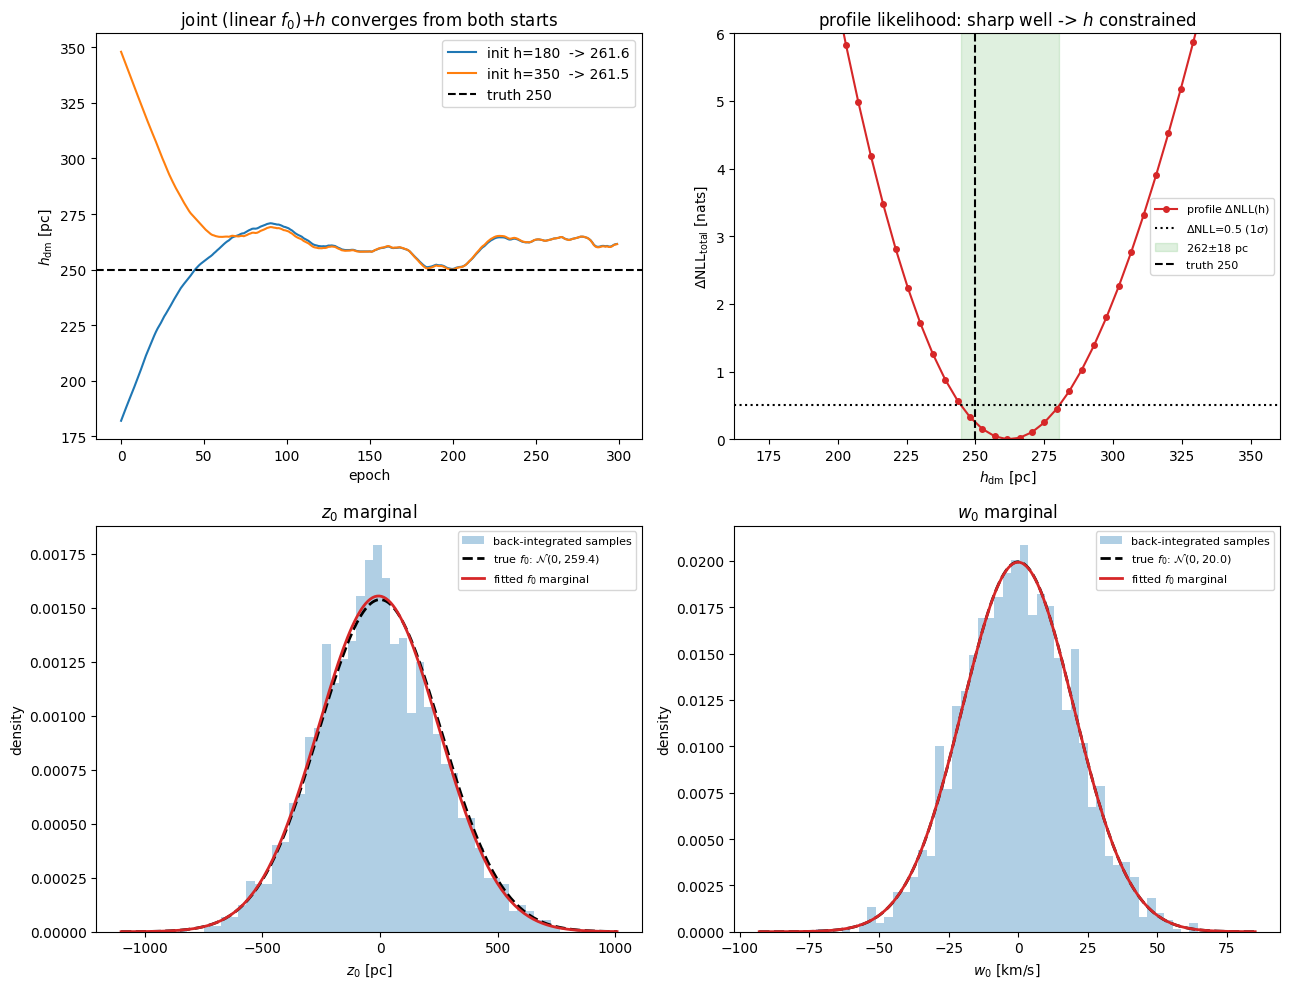

In [2]:
# ============================================================================
# TEST A -- diagonal affine flow  F(u) = a*u + b   (4 parameters)
# ============================================================================
class DiagonalAffineFlow(nn.Module):
    """Base u ~ N(0,I); data x = a*u + b (elementwise). Exactly 4 params."""
    def __init__(self, a_init=(1.0, 1.0), b_init=(0.0, 0.0)):
        super().__init__()
        self.log_a = nn.Parameter(torch.log(torch.tensor(a_init, dtype=torch.float64)))
        self.b     = nn.Parameter(torch.tensor(b_init, dtype=torch.float64))
    def log_prob(self, z, w):
        x = torch.stack([z, w], dim=1)
        u = (x - self.b) / torch.exp(self.log_a)
        return -0.5*(u**2).sum(1) - math.log(2*math.pi) - self.log_a.sum()

n_par_A = sum(p.numel() for p in DiagonalAffineFlow().parameters())
print(f"DiagonalAffineFlow parameter count = {n_par_A}  (a_z, a_w, b_z, b_w)\n")

# deliberately mis-initialise a (1.5x too wide) so the fit has to move it
mk_A = lambda: DiagonalAffineFlow(a_init=(z0_sigma*1.5, w0_sigma*1.5)).double()

t0 = time.time()
resA = {}
for hi in [180, 350]:
    flow, hf, hist = joint_fit(mk_A, hi)
    a = torch.exp(flow.log_a).detach().numpy()
    b = flow.b.detach().numpy()
    resA[hi] = dict(flow=flow, h=hf, hist=hist, a=a, b=b)
    print(f"  init h={hi:3d} -> h_fit={hf:6.1f} pc ({(hf-h_true)/h_true*100:+.1f}%)   "
          f"a=({a[0]:6.1f},{a[1]:5.2f})   b=({b[0]:+6.1f},{b[1]:+5.2f})")
print(f"\n  truth:  h={h_true:.0f}   a=({z0_sigma:.1f},{w0_sigma:.1f})   b=(0.0,0.0)")
h_est_A = float(np.mean([resA[hi]['h'] for hi in resA]))

# ---- profile likelihood in h_dm (uncertainty on h) ----------------------
# For the diagonal-Gaussian model the flow params (a,b) that MINIMISE the NLL
# at a fixed h are just the mean/std of the back-integrated cloud, so the
# profile NLL(h) = min_{a,b} NLL is CLOSED FORM (the Gaussian entropy):
#   NLL_total(h) = N * [ log(2 pi) + log sigma_z(h) + log sigma_w(h) + 1 ].
# 1 sigma interval on h: where the profile Delta(NLL) rises by 0.5 nats
# (Wilks: 2*Delta NLL ~ chi^2_1, so 1 sigma <-> Delta NLL = 0.5).
hgridA = np.linspace(h_est_A-90, h_est_A+90, 41)
def _profileA(h):
    zb, wb = backint(h)
    return N*(math.log(2*math.pi) + math.log(zb.std()) + math.log(wb.std()) + 1.0)
nllA = np.array([_profileA(h) for h in hgridA]); dnllA = nllA - nllA.min()
h_minA = hgridA[dnllA.argmin()]
lA, uA = cross(hgridA, dnllA, 0.5, -1), cross(hgridA, dnllA, 0.5, +1)
sigA = 0.5*(uA - lA)
print(f"  profile: h = {h_minA:.0f} +/- {sigA:.0f} pc  (Delta NLL = 0.5)")
print(f"  ({time.time()-t0:.0f}s)")

# ---- plots: convergence | profile-likelihood ; z0 marginal | w0 marginal ----
fig, ax = plt.subplots(2, 2, figsize=(13, 10))
for hi, r in resA.items():
    ax[0,0].plot(r['hist'], label=f'init h={hi}  -> {r["h"]:.1f}')
ax[0,0].axhline(h_true, color='k', ls='--', label=f'truth {h_true:.0f}')
ax[0,0].set_xlabel('epoch'); ax[0,0].set_ylabel(r'$h_{\rm dm}$ [pc]')
ax[0,0].set_title('joint (linear $f_0$)+$h$ converges from both starts')
ax[0,0].legend()

ax[0,1].plot(hgridA, dnllA, 'o-', color='C3', ms=4, label='profile $\\Delta$NLL(h)')
ax[0,1].axhline(0.5, color='k', ls=':', label=r'$\Delta$NLL=0.5 (1$\sigma$)')
ax[0,1].axvspan(lA, uA, color='C2', alpha=0.15,
                label=fr'{h_minA:.0f}$\pm${sigA:.0f} pc')
ax[0,1].axvline(h_true, color='k', ls='--', label=f'truth {h_true:.0f}')
ax[0,1].set_ylim(0, 6); ax[0,1].set_xlabel(r'$h_{\rm dm}$ [pc]')
ax[0,1].set_ylabel(r'$\Delta$NLL$_{\rm total}$ [nats]')
ax[0,1].set_title('profile likelihood: sharp well -> $h$ constrained')
ax[0,1].legend(fontsize=8)

r = resA[180]
plot_marginals(ax[1,0], ax[1,1], r['flow'], r['h'])
ax[1,0].set_title(r'$z_0$ marginal'); ax[1,1].set_title(r'$w_0$ marginal')
plt.tight_layout(); plt.show()


## Test B — tiny neural network, **8 parameters**

Now replace the linear map with the smallest genuine RealNVP-style flow: two
affine coupling layers.  Each layer feeds its pass-through coordinate through a
$\tanh$ non-linearity and a single `Linear(1, 2)` (scale, shift) head — 4 weights
each, **8 parameters total** — versus the thousands in the full RealNVP
(`hidden=64`).

Coordinates are first standardised by fixed (non-trainable) mean/scale buffers,
so the 8 weights only have to model the mild residual shape.  Success =
$h_{\rm dm}$ recovered near 250 from both starts, showing the heavy RealNVP is
unnecessary here.


TinyNNFlow trainable parameter count = 8   (vs RealNVP hidden=64 ~ 35344)



  init h=180 -> h_fit= 251.0 pc (+0.4%)


  init h=350 -> h_fit= 256.9 pc (+2.8%)


  profile: h = 254 +/- 30 pc  (Delta NLL = 0.5; refit noise ~0.0 nats)

  truth:  h=250      (54s)


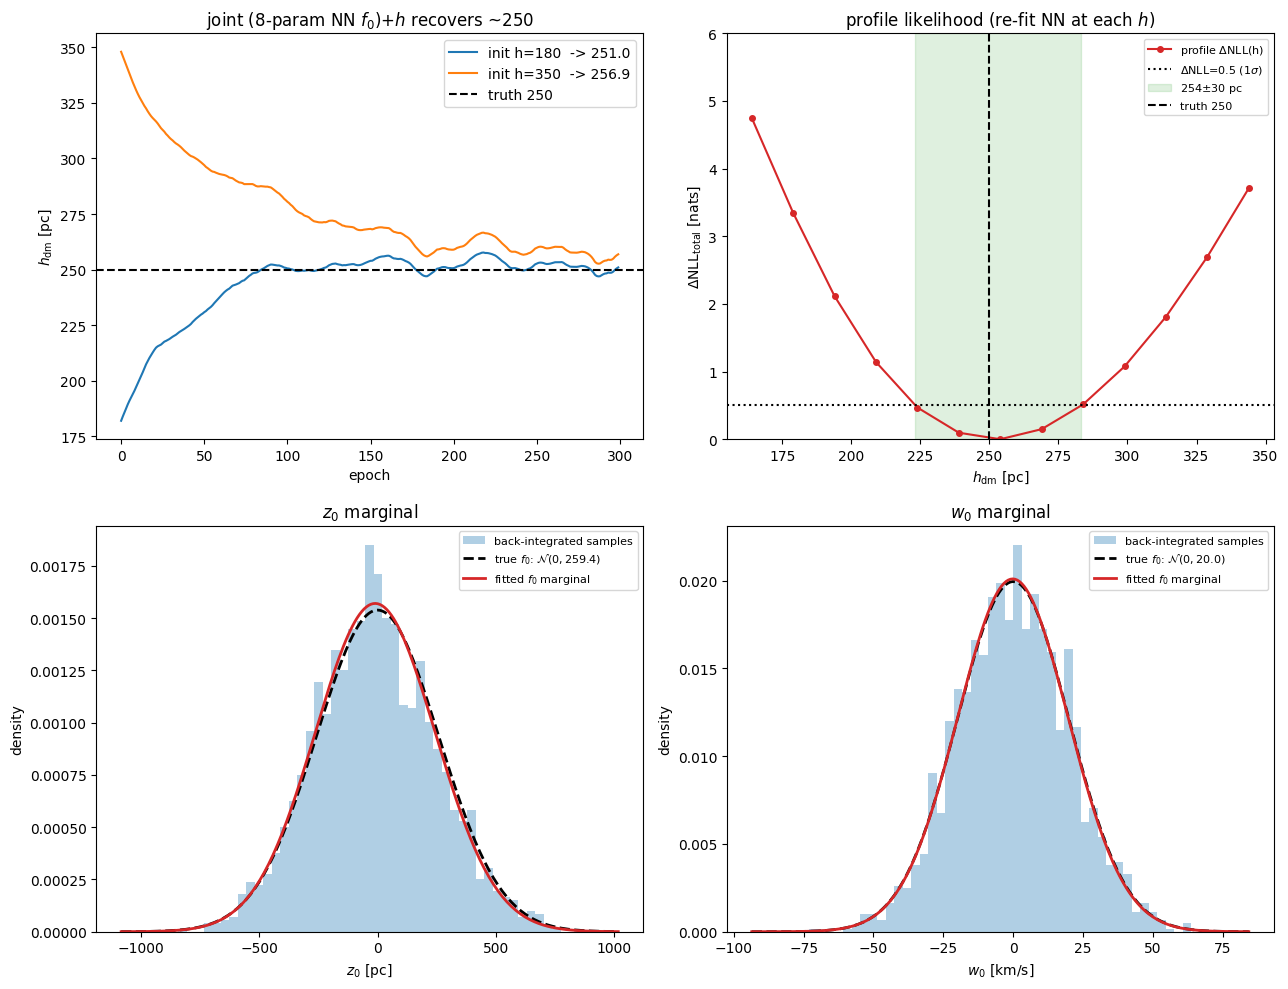


Summary: a 4-parameter linear map (Test A) and an 8-parameter NN (Test B)
both recover h_dm ~ 250 pc with a sharp profile-likelihood well -- the full
RealNVP is unnecessary when the true f0 is a single Gaussian.


In [3]:
# ============================================================================
# TEST B -- tiny NN coupling flow (8 parameters)
# ============================================================================
class TinyCoupling(nn.Module):
    """One RealNVP coupling. Non-linear (tanh) head Linear(1,2) -> (log-scale, shift).
    `flip` swaps which coordinate is transformed. 4 params each."""
    def __init__(self, flip):
        super().__init__()
        self.flip = bool(flip)
        self.lin = nn.Linear(1, 2)
        nn.init.zeros_(self.lin.weight); nn.init.zeros_(self.lin.bias)  # start = identity
    def _ss(self, a):
        st = self.lin(torch.tanh(a))               # non-linear function of conditioner
        return 1.5*torch.tanh(st[:, 0:1]/1.5), st[:, 1:2]
    def _split(self, xy):
        return (xy[:, 1:2], xy[:, 0:1]) if self.flip else (xy[:, 0:1], xy[:, 1:2])
    def _join(self, a, b):
        return torch.cat([b, a], 1) if self.flip else torch.cat([a, b], 1)
    def forward(self, xy):
        a, b = self._split(xy); s, t = self._ss(a)
        return self._join(a, (b - t)*torch.exp(-s)), -s.squeeze(-1)

class TinyNNFlow(nn.Module):
    """Two tiny couplings + fixed standardisation. 8 trainable parameters."""
    def __init__(self):
        super().__init__()
        self.layers = nn.ModuleList([TinyCoupling(flip=(i % 2 == 1)) for i in range(2)])
        self.register_buffer('mu',  torch.zeros(2, dtype=torch.float64))
        self.register_buffer('sig', torch.ones(2, dtype=torch.float64))
    def set_std(self, z, w):
        self.mu  = torch.tensor([float(np.mean(z)),  float(np.mean(w))],  dtype=torch.float64)
        self.sig = torch.tensor([float(np.std(z)),   float(np.std(w))],   dtype=torch.float64)
    def log_prob(self, z, w):
        xy = (torch.stack([z, w], 1) - self.mu) / self.sig
        ld = xy.new_zeros(xy.shape[0])
        for L in self.layers:
            xy, d = L(xy); ld = ld + d
        lb = -0.5*(xy**2).sum(1) - math.log(2*math.pi)
        return lb + ld - torch.log(self.sig).sum()

n_par_B = sum(p.numel() for p in TinyNNFlow().parameters())
print(f"TinyNNFlow trainable parameter count = {n_par_B}   "
      f"(vs RealNVP hidden=64 ~ {sum(p.numel() for p in __import__('fitter').ZWNormalizingFlow().parameters())})\n")

def mk_B():
    f = TinyNNFlow().double()
    zb, wb = backint(300.0, ns=1000)      # fixed standardisation from a rough back-integration
    f.set_std(zb, wb)
    return f

t0 = time.time()
resB = {}
for hi in [180, 350]:
    flow, hf, hist = joint_fit(mk_B, hi, lr_flow=5e-3)
    resB[hi] = dict(flow=flow, h=hf, hist=hist)
    print(f"  init h={hi:3d} -> h_fit={hf:6.1f} pc ({(hf-h_true)/h_true*100:+.1f}%)")
h_est_B = float(np.mean([resB[hi]['h'] for hi in resB]))

# ---- profile likelihood in h_dm (uncertainty on h) ----------------------
# No closed form here: at each h we RE-FIT the 8 NN params (min over the other
# parameters) and record the total NLL.  Warm-started up & down sweeps; take
# the lower envelope.  1 sigma <-> Delta NLL = 0.5 (as in Test A).
def _refit(flow, zb, wb, epochs, lr=5e-3):
    opt = torch.optim.Adam(flow.parameters(), lr=lr)
    zt, wt = torch.tensor(zb), torch.tensor(wb)
    for _ in range(epochs):
        opt.zero_grad(); loss = -flow.log_prob(zt, wt).mean(); loss.backward()
        torch.nn.utils.clip_grad_norm_(flow.parameters(), 10.0); opt.step()
    with torch.no_grad():
        return float((-flow.log_prob(zt, wt)).mean())

hgridB = np.linspace(h_est_B-90, h_est_B+90, 13)
clouds = [backint(h) for h in hgridB]
fu = mk_B(); _refit(fu, *clouds[0], 1500)
up = N*np.array([_refit(fu, *clouds[i], 400) for i in range(len(hgridB))])
fd = mk_B(); _refit(fd, *clouds[-1], 1500)
dn = N*np.array([_refit(fd, *clouds[i], 400) for i in range(len(hgridB)-1, -1, -1)])[::-1]
nllB = np.minimum(up, dn); dnllB = nllB - nllB.min()
noiseB = float(np.abs(up - dn).max())
h_minB = hgridB[dnllB.argmin()]
lB, uB = cross(hgridB, dnllB, 0.5, -1), cross(hgridB, dnllB, 0.5, +1)
sigB = 0.5*(uB - lB)
print(f"  profile: h = {h_minB:.0f} +/- {sigB:.0f} pc  (Delta NLL = 0.5; "
      f"refit noise ~{noiseB:.1f} nats)")
print(f"\n  truth:  h={h_true:.0f}      ({time.time()-t0:.0f}s)")

# ---- plots: convergence | profile-likelihood ; z0 marginal | w0 marginal ----
fig, ax = plt.subplots(2, 2, figsize=(13, 10))
for hi, r in resB.items():
    ax[0,0].plot(r['hist'], label=f'init h={hi}  -> {r["h"]:.1f}')
ax[0,0].axhline(h_true, color='k', ls='--', label=f'truth {h_true:.0f}')
ax[0,0].set_xlabel('epoch'); ax[0,0].set_ylabel(r'$h_{\rm dm}$ [pc]')
ax[0,0].set_title(f'joint ({n_par_B}-param NN $f_0$)+$h$ recovers ~250')
ax[0,0].legend()

ax[0,1].plot(hgridB, dnllB, 'o-', color='C3', ms=4, label='profile $\\Delta$NLL(h)')
ax[0,1].axhline(0.5, color='k', ls=':', label=r'$\Delta$NLL=0.5 (1$\sigma$)')
ax[0,1].axvspan(lB, uB, color='C2', alpha=0.15,
                label=fr'{h_minB:.0f}$\pm${sigB:.0f} pc')
ax[0,1].axvline(h_true, color='k', ls='--', label=f'truth {h_true:.0f}')
ax[0,1].set_ylim(0, 6); ax[0,1].set_xlabel(r'$h_{\rm dm}$ [pc]')
ax[0,1].set_ylabel(r'$\Delta$NLL$_{\rm total}$ [nats]')
ax[0,1].set_title('profile likelihood (re-fit NN at each $h$)')
ax[0,1].legend(fontsize=8)

r = resB[180]
plot_marginals(ax[1,0], ax[1,1], r['flow'], r['h'])
ax[1,0].set_title(r'$z_0$ marginal'); ax[1,1].set_title(r'$w_0$ marginal')
plt.tight_layout(); plt.show()

print("\nSummary: a 4-parameter linear map (Test A) and an 8-parameter NN (Test B)")
print("both recover h_dm ~ 250 pc with a sharp profile-likelihood well -- the full")
print("RealNVP is unnecessary when the true f0 is a single Gaussian.")
